In [ ]:
!nvidia-smi

In [23]:
from langchain_community.vectorstores import Chroma
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent

# 1. Initialize the remote LLM
NGROK_URL = "https://pamperer-handbook-dock.ngrok-free.dev/v1"

llm = ChatOpenAI(
    base_url=NGROK_URL,
    api_key="ollama",
    model="qwen3.5:9b",
    temperature=0
)

response = llm.invoke("Hello, are you ready?")
print(response.content)

Hello! Yes, I'm ready. How can I help you today?


In [33]:
from langgraph.graph import StateGraph
from typing import List, Dict, Any, TypedDict, Optional, Annotated
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import BaseMessage
from operator import add
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults


load_dotenv()

class AgentState(TypedDict):
    messages : Annotated[List[BaseMessage], add]

search_tool = TavilySearchResults(
    max_results=5,
    topic="general",
    include_image_descriptions=True,
    search_depth="basic",
   
)



In [34]:
from langgraph.prebuilt import tools_condition
from langgraph.graph import START

llm_with_tools = llm.bind_tools([search_tool])
def assistant(state: AgentState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)

    return {'messages' : [response]}


tool_node = ToolNode([search_tool])
graph = StateGraph(AgentState)
graph.add_node('assistant', assistant)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'assistant')
graph.add_conditional_edges('assistant', tools_condition)
graph.add_edge('tools', 'assistant')

chatbot = graph.compile()

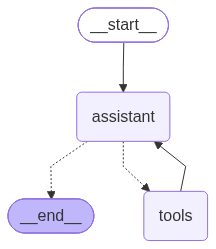

In [35]:
from IPython.display import display, Image
display(Image(chatbot.get_graph().draw_mermaid_png()))

In [37]:
chatbot.invoke({'messages': ["Who won the 2026 world cup?"]})

{'messages': ['Who won the 2026 world cup?',
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 158, 'prompt_tokens': 316, 'total_tokens': 474, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'qwen3.5:9b', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-64', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a08221-29c4-7f12-b9c4-4a8408e50113-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': '2026 FIFA World Cup winner results'}, 'id': 'call_uuo7hidh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 316, 'output_tokens': 158, 'total_tokens': 474, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}),
  ToolMessage(content='[{"title": "2026 FIFA World Cup Playoffs: Sched